### Imports
    

In [106]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_neo4j import Neo4jGraph
from neo4j import GraphDatabase
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List, Annotated
import operator
import pandas as pd
from langsmith import Client
from langgraph.types import interrupt

load_dotenv()
langsmith_client = Client()

### Connect to Neo4j and setup Anthropic


In [107]:
try:
    driver = GraphDatabase.driver(
        os.environ.get("NEO4J_URI"),
        auth=(os.environ.get("NEO4J_USERNAME"), os.environ.get("NEO4J_PASSWORD"))
    )

    driver.verify_connectivity()
    print("Neo4j connection successful")
    
    graph = Neo4jGraph(
        url=os.environ.get("NEO4J_URI"),
        username=os.environ.get("NEO4J_USERNAME"),
        password=os.environ.get("NEO4J_PASSWORD"),
        timeout=30  
    )
    

    llm = ChatAnthropic(
        model="claude-3-5-haiku-latest",
        temperature=0.3,
        anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
        max_tokens=4000
    )
    
    print("LLM initialized successfully")

except Exception as e:
    print(f"Setup failed: {e}")
    raise

Neo4j connection successful
LLM initialized successfully


### Tools setup


In [108]:
@tool
def run_cypher_query(query: str) -> str:
    """Execute a Cypher query against the Neo4j database to retrieve road network data.
    
    Use this tool when you need to:
    - Find specific roads, intersections, or traffic data
    - Query relationships between road segments
    - Get traffic incident information
    - Analyze road network connectivity
    - Search for alternative routes
    
    Args:
        query: A valid Cypher query string
        
    Returns:
        Query results as a string (limited to 50 records)
    """
    try:
        with driver.session() as session:
            result = session.run(query)
            records = [dict(record) for record in result]
            return str(records[:50])
    except Exception as e:
        return f"Query error: {str(e)}"
    
@tool 
def get_schema() -> str:
    """
    Get the Neo4j database schema including all node labels, relationship types and properties
    Use this tool FIRST before running any Cypher queries to understand:
    - What node labels exist (e.g., Road, Intersection, TrafficIncident)
    - What relationship types are available (e.g., CONNECTS_TO, HAS_INCIDENT)
    - What properties each node/relationship has
    
    This ensures your Cypher queries use correct labels, properties, and relationships
    that actually exist in the database to avoid query errors.
    
    Returns:
        Complete database schema information
    """
    try:
        schema_info = graph.get_schema
        return str(schema_info)
    except Exception as e:
        return f"Schema error: {str(e)}"

@tool 
def generate_response_plan(context: str) -> str:
    """
    Generates a response plan based on the incident context retrieved from the knowledge graph
    Input: context (string) - Comprehensive context including incident details, VMS data importantly the id,
    event with their respective plan and plan command history to provide context.
    Returns: the explicit JSON formatted response plan with actions and VMS commands not the summary.
    """
    
    # Psychological principles for VMS messaging
    psychology_guidelines = """
    PSYCHOLOGICAL PRINCIPLES FOR VMS MESSAGING:

    1. URGENCY & ATTENTION:
    - Use action words: "SLOW", "STOP", "CAUTION", "MERGE"
    - Avoid passive language: "PLEASE" or "KINDLY"
    - Create urgency without panic: "ACCIDENT AHEAD" not "CRASH"

    2. COGNITIVE LOAD REDUCTION:
    - Maximum 2 lines, 20 characters each
    - Use familiar terminology drivers understand
    - Avoid abbreviations that require mental processing
    - Use numbers for distances: "1 MILE" not "ONE MILE"

    3. EMOTIONAL RESPONSE MANAGEMENT:
    - Severity words: HIGH="MAJOR", MEDIUM="ACCIDENT", LOW="INCIDENT"
    - Calming words: "SLOW TRAFFIC" vs "TRAFFIC JAM"
    - Avoid fear words: "DANGER", "HAZARD", "RISK"

    4. BEHAVIORAL PSYCHOLOGY:
    - Give specific actions: "USE RIGHT LANE" not "AVOID LEFT"
    - Provide alternatives: "USE ALT ROUTE" when possible
    - Time-based urgency: Morning rush = more aggressive messaging

    5. DISTANCE-BASED MESSAGING:
    - 2000m+: General warning "SLOW TRAFFIC AHEAD"
    - 1000-2000m: Specific "ACCIDENT AHEAD" + "SLOW DOWN"
    - 500-1000m: Action required "MERGE RIGHT" + "ACCIDENT"
    - <500m: Immediate "SLOW" + "ACCIDENT AHEAD"

    6. TIME-BASED PSYCHOLOGY:
    - Rush hour (0700-0900, 1700-1900): More authoritative tone
    - Off-peak: Informational tone acceptable
    - Night (2200-0600): Brighter, more attention-grabbing

    7. PROVEN EFFECTIVE MESSAGES:
    - "ACCIDENT AHEAD" + "SLOW DOWN" (medium severity)
    - "MAJOR ACCIDENT" + "EXPECT DELAYS" (high severity)  
    - "SLOW TRAFFIC" + "MERGE RIGHT" (low severity)
    - "ROAD CLOSED" + "USE ALT ROUTE" (complete blockage)
    """
    
    prompt = f"""
    You are an expert in traffic management specializing in creating response plans.
    Based on traffic incident information and psychological principles, generate a comprehensive response plan.
    
    Context: {context}
    
    {psychology_guidelines}
    
    RESPONSE PLAN FORMAT:
    Generate a response plan in the following JSON format:

    {{
        "plan_type": "Traffic Management Plan",
        "priority": "High/Medium/Low",
        "estimated_duration": "X minutes/hours",
        "traffic_management_actions": [
            {{
                "eqt_no": "VMS_EQUIPMENT_ID (from EQT_NO or EQT_EXT_ID)",
                "message_line_1": "Primary message (max 20 chars)",
                "message_line_2": "Secondary message (max 20 chars)",
                "display_duration": "X minutes",
                "distance": "distance from event in meters",
                "psychological_rationale": "Why this message is psychologically effective",
                "behavioral_goal": "Desired driver behavior",
                "urgency_level": "High/Medium/Low based on distance and severity",
                "reasoning": "Give your reasoning for all of the above, why this duration etc."
            }}
        ],
        "messaging_strategy": {{
            "primary_emotion": "Urgency/Caution/Information",
            "cognitive_approach": "Simple/Clear/Direct",
            "behavioral_target": "Slow down/Merge/Avoid area"
        }},
        "emergency_response": {{
            "agencies_to_notify": [
                {{
                    "agency": "Police/Fire Services/Emergency Medical Services/Road Maintenance/Traffic Control",
                    "priority": "Immediate/High/Medium/Low",
                    "reason": "Specific reason for notification",
                    "contact_method": "Emergency dispatch/Direct call/Radio",
                    "resources_requested": "Number of units/personnel needed"
                }}
            ],
            "coordination_requirements": "How agencies should coordinate",
            "scene_management": "Who takes lead and scene control responsibilities"
        }},
        "justification": "Psychology-based explanation of messaging choices"
    }}

    EMERGENCY RESPONSE AGENCY GUIDELINES:
    1. POLICE: Required for all accidents with injuries, traffic control, investigation
    2. FIRE SERVICES: Required for vehicle fires, fuel spills, extraction operations
    3. EMERGENCY MEDICAL SERVICES: Required for any injuries, medical emergencies
    4. ROAD MAINTENANCE: Required for debris cleanup, road surface damage, barrier repairs
    5. TRAFFIC CONTROL: Required for major incidents affecting multiple lanes or extended duration
    6. TOWING SERVICES: Required for vehicle removal, clearance operations
    
    PRIORITY LEVELS:
    - Immediate: Life-threatening situations, major blockages during rush hour
    - High: Injuries present, significant traffic impact, hazardous conditions
    - Medium: Property damage only, minor traffic disruption, routine cleanup
    - Low: Minor incidents, off-peak hours, minimal impact
    
    PSYCHOLOGICAL MESSAGING RULES:
    1. Use psychology guidelines above to craft messages
    2. Consider time of day (0800 = rush hour psychology)
    3. Match message urgency to distance from incident
    4. Use action-oriented language that triggers immediate response
    5. Avoid cognitive overload - keep messages simple and clear
    6. Consider emotional state of stressed commuters

    Generate practical VMS messages that will effectively influence driver behavior and prevent secondary accidents.
    """
    
    try:
        response = llm.invoke(prompt)
        return response.content
    except Exception as e:
        return f"Error generating psychology-based response plan: {str(e)}"

# Update the tools list to include the new function
tools = [get_schema, run_cypher_query, generate_response_plan]
tool_node = ToolNode(tools)

### Parsing error handler

In [109]:
def custom_parsing_error_handler(error):
    """Custom handler to see what the LLM actually outputs"""
    print("=" * 50)
    print("PARSING ERROR DETECTED!")
    print("Error message:", str(error))
    print("=" * 50)
    
    # Try to extract the actual LLM output from the error
    error_str = str(error)
    if "Could not parse LLM output:" in error_str:
        # Extract the actual output
        start_idx = error_str.find("Could not parse LLM output:") + len("Could not parse LLM output:")
        end_idx = error_str.find("For troubleshooting")
        if end_idx == -1:
            actual_output = error_str[start_idx:].strip()
        else:
            actual_output = error_str[start_idx:end_idx].strip()
        
        print("ACTUAL LLM OUTPUT:")
        print(actual_output)
        print("=" * 50)
        
        # Return a formatted response
        return f"LLM tried to use tool but format was wrong. Raw output: {actual_output}"
    
    return f"Parsing error: {error}"

### State definition

In [110]:
class GraphState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], operator.add]
    tool_calls: List[dict]

### Workflow implementation

In [111]:
def should_continue(state: GraphState):
    """Decide whether to continue with tools or end."""
    last_message = state["messages"][-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    return "end"


def call_model(state: GraphState):
    """Call the LLM with the current state."""
    schema_docs = """
        Link nodes represent segments of the road 
        The Link node have the following properties
        from_junction, string, the junction where the link starts from
        link_id, string, the unique id for the link
        meters, string, the length of the link in meters
        to_junction, string, the junction where the link ends at

        VMS nodes represent electronic warning signs on the road
        The VMS nodes have the following properties
        DIST_TO_UPNODE, integer, distance in meters to the up node
        EQT_EXT_ID, string, the equipment unique id number
        EQT_NO, string, the equipment unique id number
        EQT_TYPE, string, the type of equipment
        ID, integer, 3-digit id of equipment
        LATITUDE, float, latitude position of equipment
        LINK_ID, integer, unique id of link where equipment is positioned
        LONGITUDE, float, longitude position of equipment
        ROAD_CAT, string, category of road equipment is placed at
        ROAD_CODE, string, code of road equipment is placed at
        ROAD_NAME, string, name of road equipment is placed at

        RELATIONSHIPS:
        The Link node and VMS node are connected by relationship LOCATED_AT which indicates where the VMS is located at it is always VMS to Link.
        They are connected by matching identical VMS (LINK_ID) to Link (link_id),
        when matching ensure for VMS it is an integer and for Link it is a string

        The Link nodes are connected by relationship CONNECTED_TO which represents the physical road network topology.
        CONNECTED_TO relationships form bidirectional connections between adjacent road segments.
        Links are connected by matching Link (to_junction) with Link (from_junction) of adjacent segments.

    """
        # System prompt for chatbot
    system_prompt = f"""
        You are a traffic incident management expert.

        CRITICAL REQUIREMENTS - DO NOT DEVIATE:
        1. ALWAYS start by performing GetSchema tool INPUT MUST BE "" WHEN DOING SO
        2. MANDATORY SECOND STEP: Check the incident link ITSELF for VMS signs first
        3. MANDATORY THIRD STEP: Find VMS signs UPSTREAM of the incident
        4. Search exactly 50 road links upstream using CONNECTED_TO*1..50
        5. FORBIDDEN: Omnidirectional search, downstream search, or limited hop search
        6. CONTINUE: If no VMS found within 50 keep going another 20 additional hops

        STEP-BY-STEP PROCESS:
        STEP 1: Get schema with GetSchema tool
        STEP 2: Check incident link for VMS using:
        MATCH (incident:Link) WHERE incident.link_id = 'INCIDENT_LINK_ID'
        MATCH (incident)<-[:LOCATED_AT]-(vms:VMS)
        WHERE toInteger(incident.link_id) = vms.LINK_ID
        RETURN vms, 0 as distance_meters, 0 as hops_from_incident

        STEP 3: Find upstream VMS using:
        MATCH (incident:Link) WHERE incident.link_id = 'INCIDENT_LINK_ID'
        MATCH path = (incident)<-[:CONNECTED_TO*1..50]-(upstream:Link)<-[:LOCATED_AT]-(vms:VMS)
        WHERE toInteger(upstream.link_id) = vms.LINK_ID
        WITH vms, upstream, path, length(path) as hops_from_incident,
            reduce(total = 0, link IN nodes(path) | total + toInteger(coalesce(link.meters, '0'))) as distance_meters
        RETURN vms, distance_meters, hops_from_incident, upstream.link_id as vms_link_id
        ORDER BY distance_meters ASC

        CORRECT CYPHER PATTERN FOR VMS SEARCH WITH DISTANCE EXAMPLES:
        ✅ INCIDENT LINK CHECK: 
        MATCH (incident:Link) WHERE incident.link_id = '17840002118812'
        MATCH (incident)<-[:LOCATED_AT]-(vms:VMS)
        WHERE toInteger(incident.link_id) = vms.LINK_ID
        RETURN vms.EQT_NO, vms.ROAD_NAME, vms.EQT_EXT_ID, 
            0 as distance_meters, 0 as hops_from_incident

        ✅ UPSTREAM SEARCH WITH DISTANCE:
        MATCH (incident:Link) WHERE incident.link_id = '17840002118812'
        MATCH path = (incident)<-[:CONNECTED_TO*1..50]-(upstream:Link)<-[:LOCATED_AT]-(vms:VMS)
        WHERE toInteger(upstream.link_id) = vms.LINK_ID
        WITH vms, upstream, path, length(path) as hops_from_incident,
            reduce(total = 0, link IN nodes(path) | total + toInteger(coalesce(link.meters, '0'))) as distance_meters
        RETURN vms.EQT_NO, vms.ROAD_NAME, vms.EQT_EXT_ID, 
            upstream.link_id as vms_link_id, 
            distance_meters, 
            hops_from_incident
        ORDER BY distance_meters ASC

        DISTANCE CALCULATION RULES:
        - IMPORTANT: link.meters is a STRING, must convert with toInteger()
        - Use: toInteger(coalesce(link.meters, '0')) to handle null values
        - For incident link itself: distance = 0 meters, hops = 0
        - For upstream VMS: sum all converted link.meters values in the path
        - Always include distance_meters and hops_from_incident in your results
        - Order results by distance_meters ASC to show closest VMS first

        ❌ WRONG: MATCH (upstream:Link)<-[:CONNECTED_TO*1..50]-(incident:Link)
        ❌ WRONG: MATCH (incident:Link)-[:CONNECTED_TO*1..50]->(upstream:Link)
        ❌ WRONG: total + link.meters (this won't work - meters is a string!)

        DIRECTION RULE: Arrow MUST point toward the incident: upstream -> incident
        This means: (incident)<-[:CONNECTED_TO*1..50]-(upstream)

        {schema_docs}
        Use the documentation above to understand what each node/edge means

        TRAFFIC FLOW RULES:
        - Upstream = where traffic comes FROM (toward incident) 
        - Use arrow syntax: incident<-[:CONNECTED_TO*1..50]-upstream
        - This finds links where traffic flows toward the incident

        Your mission: Find upstream VMS to warn approaching drivers and prevent secondary accidents.
        Always report the distance in meters and number of hops for each VMS found.
        Use SelfReflect tool whenever you encounter challenges or need to evaluate your approach.
        Remember: link.meters is a STRING - always convert with toInteger()!
    """
    
    # Convert state messages to proper format
    system_message = {"role": "system", "content": system_prompt}
    
    # Get existing messages from state
    messages = [system_message] + state["messages"]
    
    # Bind tools to the LLM
    llm_with_tools = llm.bind_tools(tools)
    
    # Pass messages directly without conversion
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

def human_node(state: GraphState):
    value = interrupt(
        
    )


# Build the graph
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Set entry point
workflow.set_entry_point("agent")

# Add conditional edges
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)

# Add edge from tools back to agent
workflow.add_edge("tools", "agent")

# Compile the graph
app = workflow.compile()

### WorkFlow viz

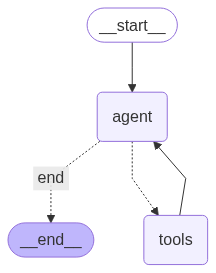

In [112]:
# Add this import at the top with your other imports
from IPython.display import Image, display
import io
import base64

# Add this cell after your workflow compilation
try:
    # Get the graph visualization
    graph_image = app.get_graph().draw_mermaid_png()
    
    # Display the image
    display(Image(graph_image))
    
except Exception as e:
    print(f"Visualization error: {e}")
    print("Trying alternative method...")
    
    # Alternative: Print the graph structure
    try:
        graph_dict = app.get_graph().to_json()
        print("Graph Structure:")
        print("=" * 50)
        print(f"Nodes: {list(graph_dict.get('nodes', {}).keys())}")
        print(f"Edges: {graph_dict.get('edges', [])}")
        
        
    except Exception as e2:
        print(f"Alternative visualization failed: {e2}")

### Initialize chatbot

In [113]:
class RoadNetworkChatBot:
    def __init__(self, verbose = True):
        self.app = app
        self.verbose = verbose
    
    def query(self, question: str, run_name: str = None):
        try:
            if self.verbose:
                print(f"Starting query: {question}")

            # Create initial state
            initial_state = {
                "messages": [HumanMessage(content=question)],
                "tool_calls": []
            }

            config = {
                "run_name": run_name or f"traffic_query_{len(question.split())}_words",
                "tags": ["traffic-management", "neo4j", "langgraph"],
                "metadata": {
                    "question_type": "traffic_incident" if "incident" in question.lower() else "general",
                    "question_length": len(question),
                    "timestamp": str(pd.Timestamp.now())
                }
            }

            if self.verbose:
                print("Running workflow...")

            # Run the graph
            result = self.app.invoke(initial_state, config = config)

            if self.verbose:
                print(f"✅ Workflow completed with {len(result['messages'])} messages")
            
            # Extract the final response
            final_message = result["messages"][-1]
            return final_message.content
            
        except Exception as e:
            if self.verbose:
                print(f"❌ Error occurred: {e}")
            return f"Error: {e}"
    
    def stream_query(self, question: str, run_name: str = None):
        """Stream the response for real-time updates."""
        initial_state = {
            "messages": [HumanMessage(content=question)],
            "tool_calls": []
        }

        config = {
            "run_name": run_name or f"stream_traffic_query",
            "tags": ["traffic-management", "streaming", "neo4j"],
            "metadata": {"streaming": True}
        }
        
        for chunk in self.app.stream(initial_state, config = config):
            if self.verbose:
                print(f"📦 Chunk received: {list(chunk.keys())}")
            yield chunk


            

### Performance tracker


In [114]:
test_queries = []

def test_and_track_query(chatbot, question: str, expected_outcome: str = None):
    """Test a query and track performance in LangSmith."""
    import time
    
    start_time = time.time()
    
    try:
        result = chatbot.query(
            question, 
            run_name=f"test_{len(test_queries)+1}_{question[:20].replace(' ', '_')}"
        )
        
        end_time = time.time()
        duration = end_time - start_time
        
        # Store test result
        test_result = {
            "query": question,
            "result": result,
            "duration": duration,
            "expected": expected_outcome,
            "timestamp": time.time(),
            "success": "Error:" not in result
        }
        
        test_queries.append(test_result)
        
        print(f"Query: {question}")
        print(f"Duration: {duration:.2f}s")
        print(f"Result: {result}")
        print("-" * 50)
        
        return test_result
        
    except Exception as e:
        print(f"Test failed: {e}")
        return None

### Tests

In [ ]:
chatbot = RoadNetworkChatBot()
incident_query = "There's a major accident on link 17840002118812. Generate a response plan."
result = chatbot.query(incident_query)


Starting query: There's a major accident on link 17840002118812. Generate a response plan.
Running workflow...
✅ Workflow completed with 10 messages


In [118]:


def test_with_streaming_human_loop(question):
    print("=" * 60)
    print(f"STREAMING TEST WITH HUMAN REVIEW: {question}")
    print("=" * 60)
    
    for chunk in chatbot.stream_query(question):
        for node, output in chunk.items():
            print(f"\n🔄 Node: {node}")
            if "messages" in output:
                for msg in output["messages"]:
                    if hasattr(msg, 'content'):
                        # Truncate very long content for readability
                        content = msg.content
                        if hasattr(msg, 'type') and msg.type == 'ai':
                            print(f"🧠 AI Thought Process:")
                            print(f"{content}")
                        else:
                            print(f"💬 Content: {content}")
                    if hasattr(msg, 'tool_calls') and msg.tool_calls:
                        print(f"🔧 Tool calls: {[tc.get('name', 'unknown') for tc in msg.tool_calls]}")

                        for i, tool_call in enumerate(msg.tool_calls):
                            tool_name = tool_call.get('name', 'unknown')
                            tool_args = tool_call.get('args', {})
                            print(f"   Tool {i+1}: {tool_name}")
                            if tool_name == 'run_cypher_query':
                                query = tool_args.get('query', '')
                                print(f"   📝 Query: {query}")
                            elif tool_name == 'generate_response_plan':
                                context = tool_args.get('context', '')
                                print(f"   📋 Context length: {len(context)} characters")

            if node == "tools" and "messages" in output:
                for msg in output["messages"]:
                    if hasattr(msg, 'content') and hasattr(msg, 'name'):
                        tool_name = msg.name
                        result = msg.content
                        print(f"⚙️ Tool '{tool_name}' executed:")
                        print(f"📊 Result: {result}")
            
            # Show human feedback if present
            if "human_feedback" in output:
                print(f"👤 Human Feedback: {output['human_feedback']}")
            if "final_approved" in output:
                print(f"✅ Final Approval: {output['final_approved']}")

# Update the test to use the new function
print("\n" + "="*80)
print("🧪 TESTING WORKFLOW WITH HUMAN-IN-THE-LOOP")
print("="*80)

# Initialize chatbot
chatbot = RoadNetworkChatBot(verbose=True)

# Test with human review
test_with_streaming_human_loop("A car accident has occurred at link_id 17840006094278, the time is 0800, the event severity is medium, the event type is accident")
# Run tests with tracking
# for query in test_queries_list:
#     test_and_track_query(chatbot, query)

# # Print summary
# print(f"\nTotal tests run: {len(test_queries)}")
# print(f"Successful tests: {sum(1 for t in test_queries if t['success'])}")
# print(f"Average duration: {sum(t['duration'] for t in test_queries) / len(test_queries):.2f}s")



🧪 TESTING WORKFLOW WITH HUMAN-IN-THE-LOOP
STREAMING TEST WITH HUMAN REVIEW: A car accident has occurred at link_id 17840006094278, the time is 0800, the event severity is medium, the event type is accident
📦 Chunk received: ['agent']

🔄 Node: agent
🧠 AI Thought Process:
[{'text': "I'll help you manage this traffic incident systematically by following the prescribed steps.\n\nSTEP 1: Get Database Schema", 'type': 'text'}, {'id': 'toolu_019aD5UAQ9ZxDdXCNXdbhXmx', 'input': {}, 'name': 'get_schema', 'type': 'tool_use'}]
🔧 Tool calls: ['get_schema']
   Tool 1: get_schema
📦 Chunk received: ['tools']

🔄 Node: tools
💬 Content: Node properties:
VMS {ID: INTEGER, EQT_NO: STRING, LONGITUDE: FLOAT, DIST_TO_UPNODE: INTEGER, ROAD_NAME: STRING, DIR: FLOAT, ROAD_CODE: STRING, EQT_TYPE: STRING, EQT_EXT_ID: STRING, ROAD_CAT: STRING, LINK_ID: INTEGER, LATITUDE: FLOAT}
Link {from_junction: STRING, link_id: STRING, to_junction: STRING, meters: STRING}
Relationship properties:
CONNECTED_TO {junction_id: ST

Work for 15/07/25
1. Fix the human in the loop
2. Test the changes due to human in the loop
3. understand the work flow 
4. test the memory and ensure there is no issue